![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [2]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline

In [5]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [6]:
df.shape

(541462, 3)

In [7]:
# Impresión histograma de variable de interés (y)
df.target.hist()

<Axes: >

In [8]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [9]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [10]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [11]:
# Celda 1 - CountVectorizer básico con Ridge Regression
from sklearn.linear_model import Ridge

# Tokenización con CountVectorizer
vect_count = CountVectorizer()
X_train_count = vect_count.fit_transform(X_train)
X_test_count = vect_count.transform(X_test)

# Entrenamiento y predicción
model_count = Ridge()
model_count.fit(X_train_count, y_train)
y_pred_count = model_count.predict(X_test_count)

mse_count = metrics.mean_squared_error(y_test, y_pred_count)
print(f'MSE CountVectorizer: {mse_count:.6f}')

MSE CountVectorizer: 0.026127


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [12]:
# Celda 2 - CountVectorizer con trigramas
vect_trigram = CountVectorizer(ngram_range=(1, 3))
X_train_trigram = vect_trigram.fit_transform(X_train)
X_test_trigram = vect_trigram.transform(X_test)

model_trigram = Ridge()
model_trigram.fit(X_train_trigram, y_train)
y_pred_trigram = model_trigram.predict(X_test_trigram)

mse_trigram = metrics.mean_squared_error(y_test, y_pred_trigram)
print(f'MSE CountVectorizer + Trigramas: {mse_trigram:.6f}')

MSE CountVectorizer + Trigramas: 0.033322


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

In [13]:
### Celda 3 - Explicación TfidfVectorizer

**¿Qué es TF-IDF?**
TF-IDF (Term Frequency - Inverse Document Frequency) es una técnica de tokenización que pondera cada palabra según dos factores:
- **TF (Term Frequency):** Frecuencia de la palabra en el documento.
- **IDF (Inverse Document Frequency):** Penaliza palabras que aparecen en muchos documentos (como "the", "is", "a"), asignándoles menor peso.

El valor final es el producto TF × IDF, lo que resalta palabras que son frecuentes en un documento pero raras en el corpus general.

**Ventajas vs CountVectorizer:**
- Reduce el peso de palabras muy comunes que aportan poca información.
- Suele mejorar el desempeño de los modelos al capturar mejor la relevancia de cada término.

**Desventajas vs CountVectorizer:**
- Mayor costo computacional por el cálculo del IDF.
- Puede perder información al penalizar palabras frecuentes que sí sean relevantes en ciertos contextos.

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [14]:
# Celda 4 - TfidfVectorizer
vect_tfidf = TfidfVectorizer()
X_train_tfidf = vect_tfidf.fit_transform(X_train)
X_test_tfidf = vect_tfidf.transform(X_test)

model_tfidf = Ridge()
model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

mse_tfidf = metrics.mean_squared_error(y_test, y_pred_tfidf)
print(f'MSE TfidfVectorizer: {mse_tfidf:.6f}')

MSE TfidfVectorizer: 0.018051


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.

                     Método      MSE
            CountVectorizer 0.026127
CountVectorizer + Trigramas 0.033322
            TfidfVectorizer 0.018051


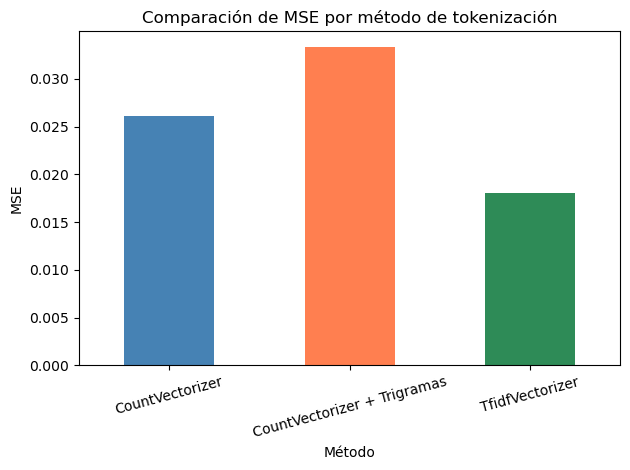

In [16]:
# Celda 5 - Tabla y gráfico comparativo
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    'Método': ['CountVectorizer', 'CountVectorizer + Trigramas', 'TfidfVectorizer'],
    'MSE': [mse_count, mse_trigram, mse_tfidf]
})
print(resultados.to_string(index=False))

# Gráfico de barras
resultados.plot(x='Método', y='MSE', kind='bar', legend=False, color=['steelblue', 'coral', 'seagreen'])
plt.ylabel('MSE')
plt.title('Comparación de MSE por método de tokenización')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Punto 5.1 - Análisis de resultados

| Método | MSE |
|--------|-----|
| CountVectorizer | 0.0261 |
| CountVectorizer + Trigramas | 0.0333 |
| TfidfVectorizer | **0.0181** |

**Observaciones:**
- **TfidfVectorizer** obtuvo el menor MSE (0.0181), confirmando que ponderar palabras por su importancia relativa mejora la predicción.
- **CountVectorizer básico** (0.0261) funciona razonablemente bien como línea base con solo frecuencias de unigramas.
- **CountVectorizer con trigramas** (0.0333) tuvo el peor desempeño. La alta dimensionalidad generada por los trigramas probablemente introduce ruido que dificulta la generalización del modelo.

**Conclusión:** El preprocesamiento de texto impacta directamente en el desempeño. TF-IDF supera al conteo simple al capturar mejor la relevancia de cada término, mientras que agregar n-gramas sin control de dimensionalidad puede ser contraproducente.